# Tests de Validation - Modèles de Clustering KMeans
Tests de robustesse, performance et cas limites pour les modèles de clustering non-supervisés

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

SEED = 42


### Connexion à la DB / Import des Données

In [2]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
con = duckdb.connect(str(DB_NAME))

# Show available tables
print("Tables disponibles:")
con.sql("SHOW TABLES").show()

Tables disponibles:
┌──────────────────────────────┐
│             name             │
│           varchar            │
├──────────────────────────────┤
│ all_events                   │
│ loaded_files                 │
│ user_events                  │
│ user_events_11_2019          │
│ user_segments_11_2019_kmeans │
│ user_segments_kmeans         │
└──────────────────────────────┘



### Chargement des Features Utilisateurs

In [3]:
# Configuration
TABLE_USER_EVENTS = "user_events_11_2019"  # Ajuster selon votre table
SAMPLE_PERCENT = 0.05  # Pour tests rapides, utiliser un échantillon
N_CLUSTERS = 4  # Nombre de clusters pour KMeans

# Charger les données
user_events_df = con.execute(f"""
    SELECT 
        user_id,
        total_events,
        total_views,
        total_purchases,
        avg_time_between_events,
        total_spent,
        avg_basket,
        conversion_rate,
        purchase_ratio,
        days_since_last_event
    FROM {TABLE_USER_EVENTS}
    WHERE user_id IS NOT NULL
""").fetch_df()

print(f"Dataset complet: {len(user_events_df)} utilisateurs")
print(f"\nAperçu des données:")
print(user_events_df.head())
print(f"\nStatistiques descriptives:")
print(user_events_df.describe())

Dataset complet: 1359785 utilisateurs

Aperçu des données:
     user_id  total_events  total_views  total_purchases  \
0  553150326            22         20.0              2.0   
1  578219283            16         16.0              0.0   
2  567592718            14         13.0              0.0   
3  558040401            27         27.0              0.0   
4  512896421            11         11.0              0.0   

   avg_time_between_events  total_spent  avg_basket  conversion_rate  \
0               124.857143       2797.5     1398.75              0.1   
1                73.733333          0.0        0.00              0.0   
2            170643.384615          0.0        0.00              0.0   
3             78091.384615          0.0        0.00              0.0   
4            184719.100000          0.0        0.00              0.0   

   purchase_ratio  days_since_last_event  
0        0.090909                    151  
1        0.000000                    124  
2        0.000000 

In [4]:
# Échantillonnage pour tests
user_events_sample = user_events_df.sample(frac=SAMPLE_PERCENT, random_state=SEED)
print(f"Échantillon pour tests: {len(user_events_sample)} utilisateurs")

# Préparation des features (exclusion user_id)
feature_cols = [col for col in user_events_sample.columns if col != 'user_id']
X = user_events_sample[feature_cols].values

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape des features: {X_scaled.shape}")

Échantillon pour tests: 67989 utilisateurs
Shape des features: (67989, 9)


# Nettoyage des clonnes inutiles

In [5]:
user_events_df.drop(columns=["days_since_last_event","conversion_rate","avg_time_between_events","purchase_ratio"], inplace=True)

### Entraînement du Modèle KMeans de Référence

In [6]:
# Entraînement du modèle de référence
kmeans_ref = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, init='k-means++')
labels_ref = kmeans_ref.fit_predict(X_scaled)

# Métriques de référence
silhouette_ref = silhouette_score(X_scaled, labels_ref)
davies_bouldin_ref = davies_bouldin_score(X_scaled, labels_ref)
calinski_ref = calinski_harabasz_score(X_scaled, labels_ref)
inertia_ref = kmeans_ref.inertia_

print("=== Modèle de Référence ===")
print(f"Silhouette Score: {silhouette_ref:.4f} (plus élevé = meilleur, [-1, 1])")
print(f"Davies-Bouldin Index: {davies_bouldin_ref:.4f} (plus bas = meilleur)")
print(f"Calinski-Harabasz Score: {calinski_ref:.4f} (plus élevé = meilleur)")
print(f"Inertia: {inertia_ref:.2f} (somme distances carrées)")

# Distribution des clusters
print(f"\nDistribution des clusters:")
unique, counts = np.unique(labels_ref, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} utilisateurs ({count/len(labels_ref)*100:.1f}%)")

=== Modèle de Référence ===
Silhouette Score: 0.2809 (plus élevé = meilleur, [-1, 1])
Davies-Bouldin Index: 1.1571 (plus bas = meilleur)
Calinski-Harabasz Score: 17605.2388 (plus élevé = meilleur)
Inertia: 344369.67 (somme distances carrées)

Distribution des clusters:
  Cluster 0: 27007 utilisateurs (39.7%)
  Cluster 1: 5375 utilisateurs (7.9%)
  Cluster 2: 31731 utilisateurs (46.7%)
  Cluster 3: 3876 utilisateurs (5.7%)


## 1. Tests de Robustesse au Bruit
Vérifier la stabilité du clustering face à des perturbations des features

| Champ              | Contenu attendu                         |
|--------------------|------------------------------------------|
| ID du test         | TST-CLU-001                               |
| Objectif du test   | Vérifier la robustesse au bruit          |
| Description        | Ajouter du bruit gaussien aux features   |
| Données utilisées  | User events features avec bruit          |
| Méthode            | Injection de bruit aléatoire (Gaussian)  |
| Résultat attendu   | Silhouette Score ≥ 0.15, stabilité clusters |
| Résultat obtenu    | À compléter après exécution              |
| Statut             | En cours                                 |
| Commentaire        | Évalue la sensibilité aux variations des données |

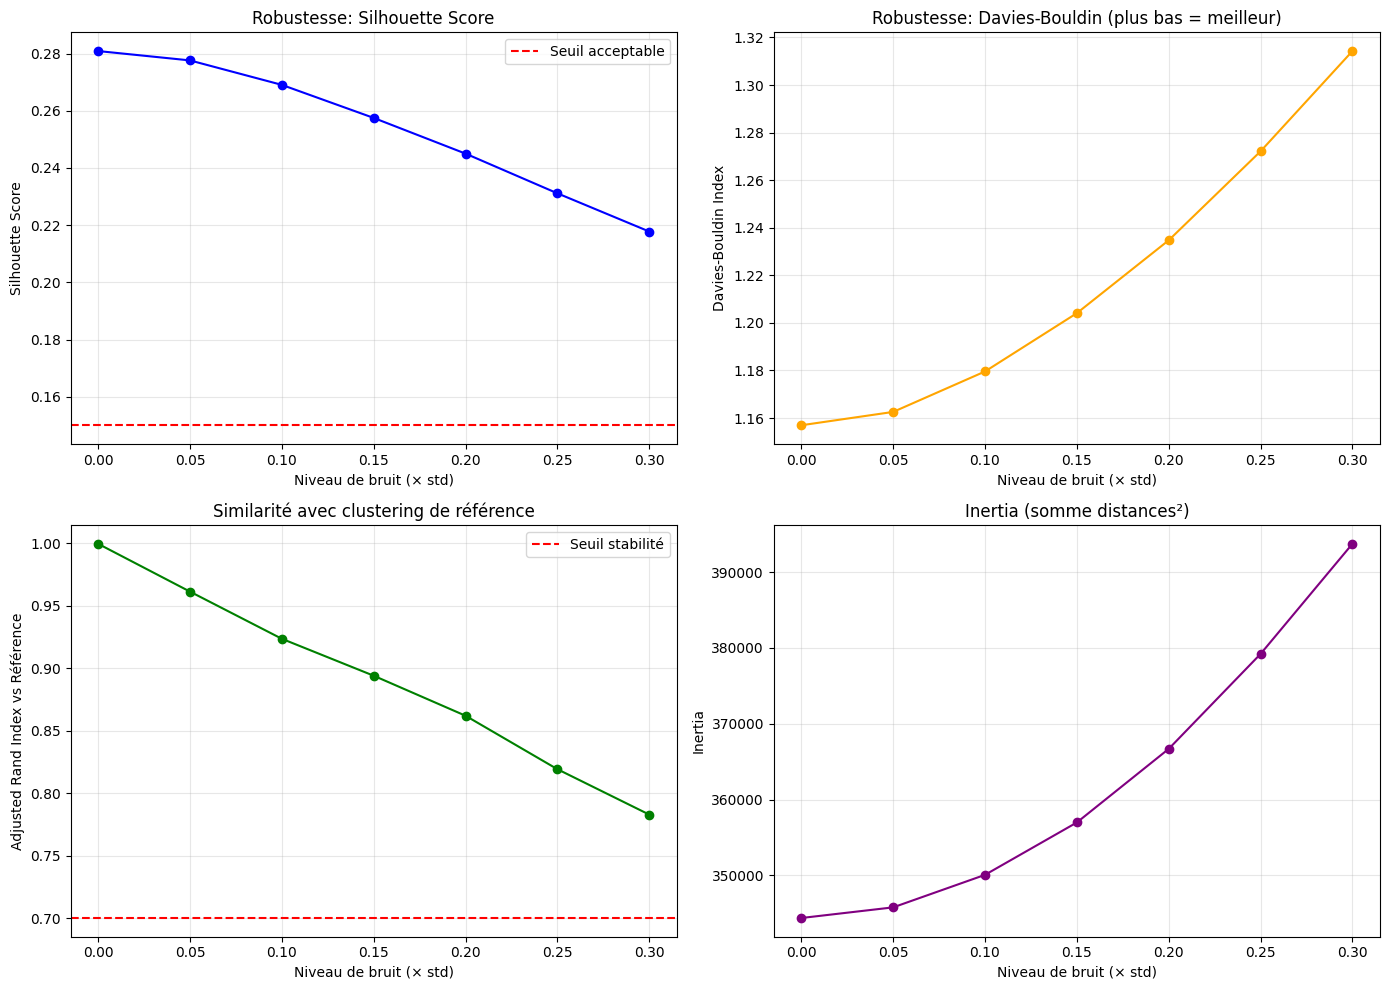


=== Résumé Robustesse au Bruit ===
Bruit=0.00 | Silhouette=0.2809 | Davies-Bouldin=1.1570 | ARI=0.9995
Bruit=0.05 | Silhouette=0.2776 | Davies-Bouldin=1.1626 | ARI=0.9612
Bruit=0.10 | Silhouette=0.2691 | Davies-Bouldin=1.1796 | ARI=0.9235
Bruit=0.15 | Silhouette=0.2575 | Davies-Bouldin=1.2041 | ARI=0.8939
Bruit=0.20 | Silhouette=0.2450 | Davies-Bouldin=1.2348 | ARI=0.8619
Bruit=0.25 | Silhouette=0.2311 | Davies-Bouldin=1.2722 | ARI=0.8191
Bruit=0.30 | Silhouette=0.2178 | Davies-Bouldin=1.3143 | ARI=0.7827


In [7]:
def add_gaussian_noise(X, noise_level):
    """Ajoute un bruit gaussien avec écart-type = noise_level * std(X)"""
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

def adjusted_rand_score_clusters(labels1, labels2):
    """Calcule la similarité entre deux assignations de clusters"""
    from sklearn.metrics import adjusted_rand_score
    return adjusted_rand_score(labels1, labels2)

# Test de robustesse au bruit
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

silhouette_scores = []
davies_bouldin_scores = []
ari_scores = []  # Adjusted Rand Index vs référence
inertias = []

for noise_lvl in noise_levels:
    # Ajouter du bruit
    X_noisy = add_gaussian_noise(X_scaled, noise_lvl)
    
    # Entraîner KMeans sur données bruitées
    kmeans_noisy = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
    labels_noisy = kmeans_noisy.fit_predict(X_noisy)
    
    # Calculer métriques
    sil = silhouette_score(X_noisy, labels_noisy)
    db = davies_bouldin_score(X_noisy, labels_noisy)
    ari = adjusted_rand_score_clusters(labels_ref, labels_noisy)
    inertia = kmeans_noisy.inertia_
    
    silhouette_scores.append(sil)
    davies_bouldin_scores.append(db)
    ari_scores.append(ari)
    inertias.append(inertia)

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(noise_levels, silhouette_scores, marker='o', color='blue')
axes[0, 0].axhline(y=0.15, color='r', linestyle='--', label='Seuil acceptable')
axes[0, 0].set_xlabel('Niveau de bruit (× std)')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Robustesse: Silhouette Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(noise_levels, davies_bouldin_scores, marker='o', color='orange')
axes[0, 1].set_xlabel('Niveau de bruit (× std)')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Robustesse: Davies-Bouldin (plus bas = meilleur)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(noise_levels, ari_scores, marker='o', color='green')
axes[1, 0].axhline(y=0.7, color='r', linestyle='--', label='Seuil stabilité')
axes[1, 0].set_xlabel('Niveau de bruit (× std)')
axes[1, 0].set_ylabel('Adjusted Rand Index vs Référence')
axes[1, 0].set_title('Similarité avec clustering de référence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(noise_levels, inertias, marker='o', color='purple')
axes[1, 1].set_xlabel('Niveau de bruit (× std)')
axes[1, 1].set_ylabel('Inertia')
axes[1, 1].set_title('Inertia (somme distances²)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Résumé textuel
print("\n=== Résumé Robustesse au Bruit ===")
for i, noise in enumerate(noise_levels):
    print(f"Bruit={noise:.2f} | Silhouette={silhouette_scores[i]:.4f} | "
          f"Davies-Bouldin={davies_bouldin_scores[i]:.4f} | "
          f"ARI={ari_scores[i]:.4f}")

## 2. Tests de Biais - Distribution des Clusters
Vérifier si les clusters sont équilibrés et représentatifs

| Champ              | Contenu attendu                         |
|--------------------|------------------------------------------|
| ID du test         | TST-CLU-002                               |
| Objectif du test   | Identifier des biais dans le clustering  |
| Description        | Analyser la distribution et les caractéristiques des clusters |
| Données utilisées  | User events features                     |
| Méthode            | Analyse statistique par cluster          |
| Résultat attendu   | Clusters équilibrés et distincts         |
| Résultat obtenu    | À compléter après exécution              |
| Statut             | En cours                                 |

=== Statistiques par Cluster ===


--- Cluster 0 (27007 utilisateurs) ---
       total_events  total_views  total_purchases  avg_time_between_events  \
count      27007.00     27007.00         27007.00                 27007.00   
mean          30.75        29.19             0.22                 16738.63   
std           23.95        22.98             0.56                 19239.39   
min           10.00         1.00             0.00                     0.22   
25%           14.00        13.00             0.00                   567.91   
50%           22.00        21.00             0.00                 10086.02   
75%           38.00        36.00             0.00                 26011.06   
max          155.00       146.00             7.00                107726.78   

       total_spent  avg_basket  conversion_rate  purchase_ratio  \
count     27007.00    27007.00         27007.00        27007.00   
mean         37.74       29.54             0.01            0.01   
std         121.00    

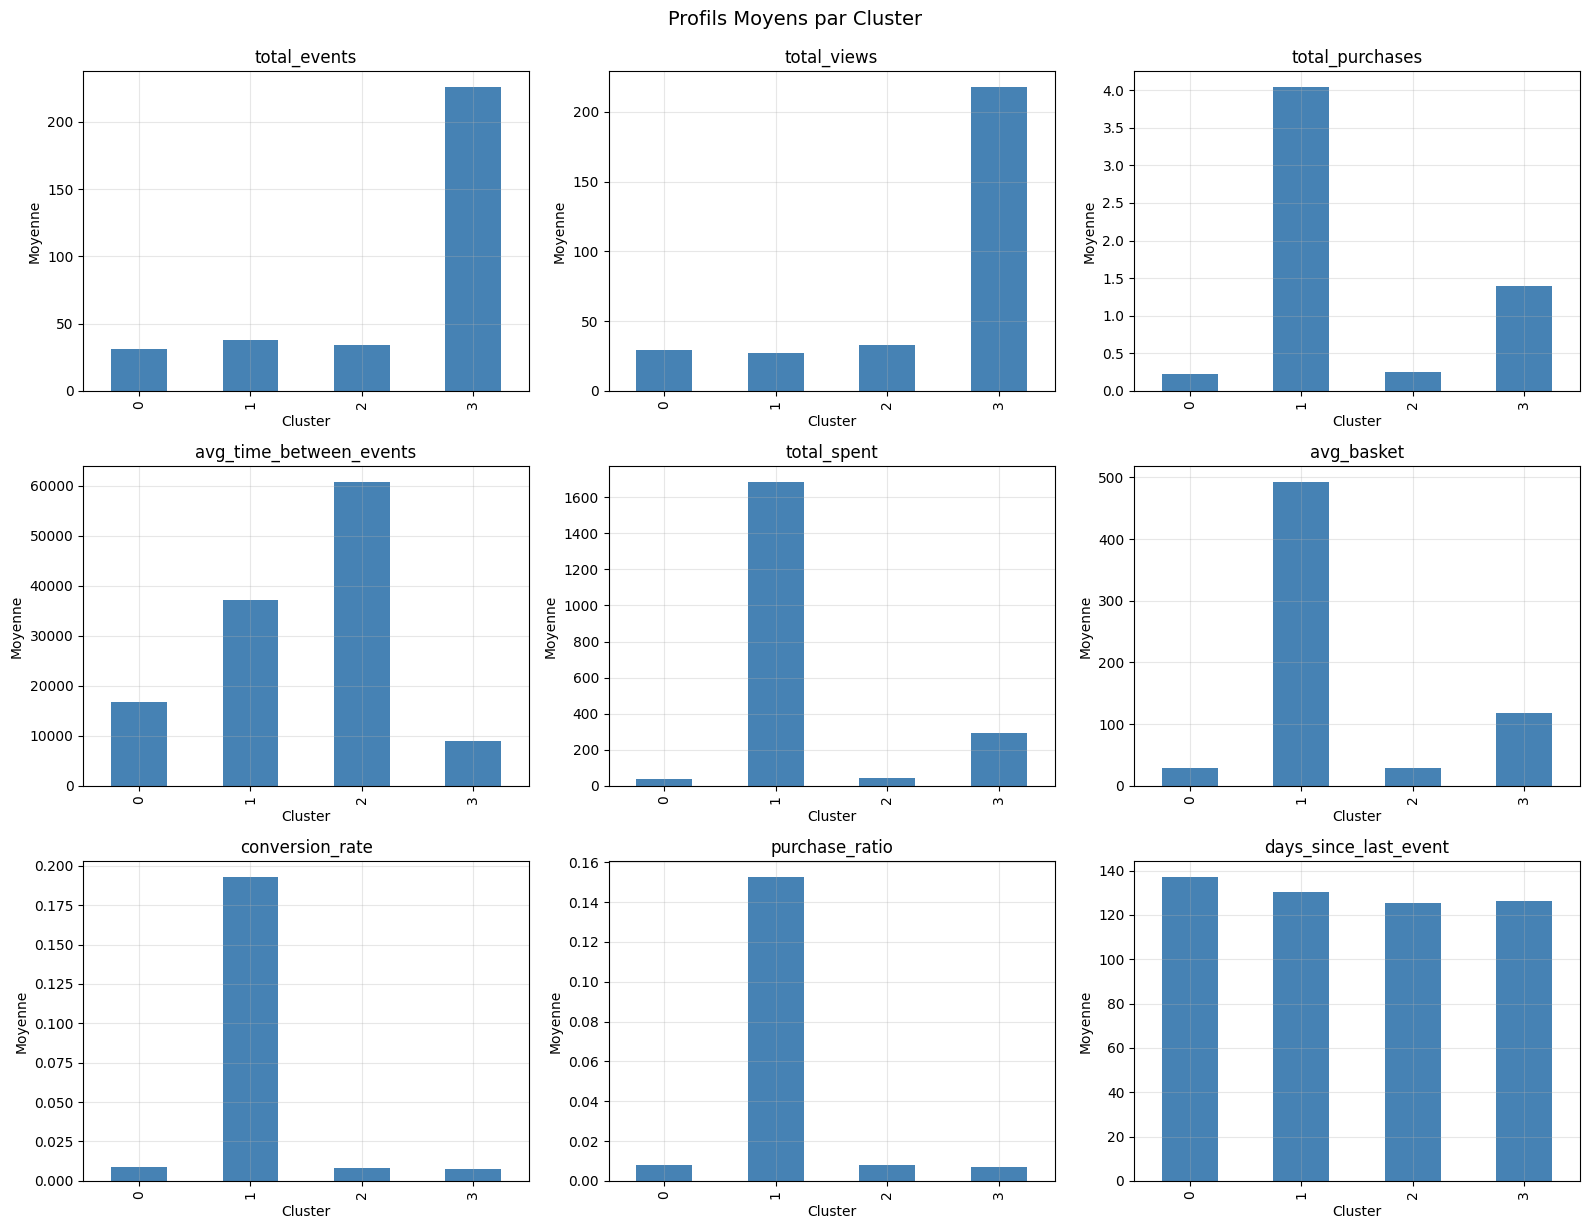

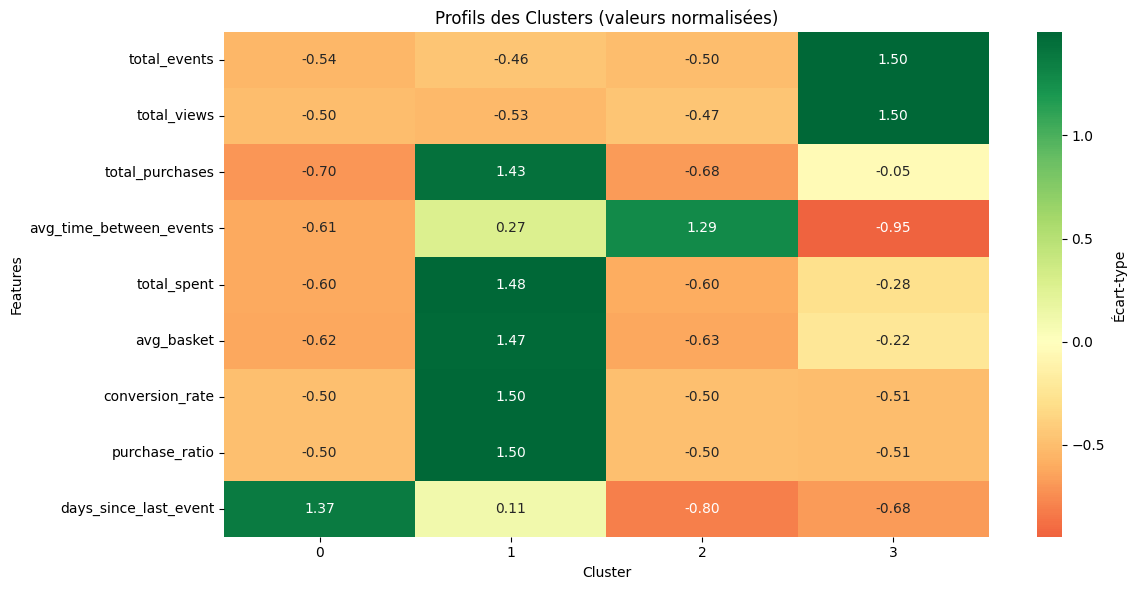

In [8]:
# Analyse des clusters
user_events_sample['cluster'] = labels_ref

# Statistiques par cluster
print("=== Statistiques par Cluster ===\n")
for cluster in range(N_CLUSTERS):
    cluster_data = user_events_sample[user_events_sample['cluster'] == cluster]
    print(f"\n--- Cluster {cluster} ({len(cluster_data)} utilisateurs) ---")
    print(cluster_data[feature_cols].describe().round(2))

# Visualisation des moyennes par cluster
cluster_means = user_events_sample.groupby('cluster')[feature_cols].mean()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if i < len(axes):
        cluster_means[col].plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('Moyenne')
        axes[i].grid(True, alpha=0.3)

# Supprimer axes vides
for i in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Profils Moyens par Cluster', y=1.02, fontsize=14)
plt.show()

# Heatmap des moyennes normalisées
cluster_means_scaled = (cluster_means - cluster_means.mean()) / cluster_means.std()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_scaled.T, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, cbar_kws={'label': 'Écart-type'})
plt.title('Profils des Clusters (valeurs normalisées)')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 3. Tests de Performance - Métriques de Clustering
Évaluation quantitative de la qualité du clustering

| Champ              | Contenu attendu                         |
|--------------------|------------------------------------------|
| ID du test         | TST-CLU-003                               |
| Objectif du test   | Évaluer la qualité du clustering         |
| Description        | Calculer plusieurs métriques de performance |
| Données utilisées  | User events features                     |
| Méthode            | Silhouette, Davies-Bouldin, Calinski-Harabasz |
| Résultat attendu   | Silhouette > 0.2, DB < 1.5               |
| Résultat obtenu    | À compléter après exécution              |
| Statut             | En cours                                 |

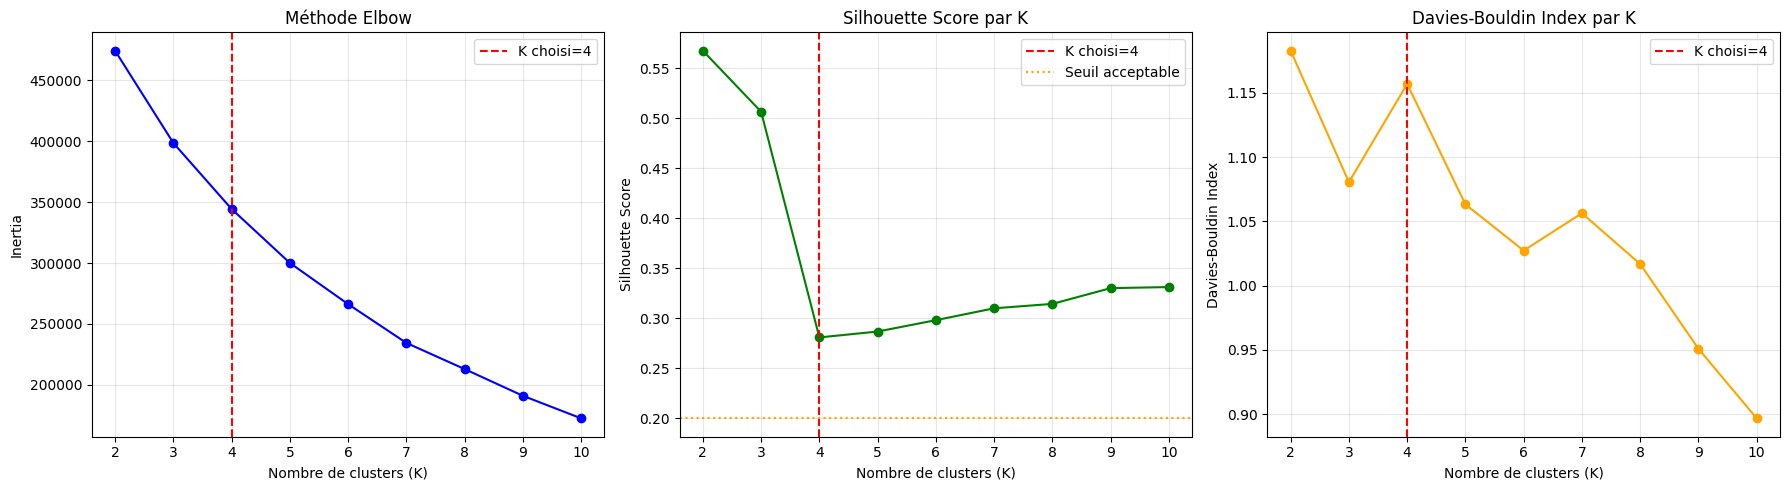


=== Résumé Performance par K ===
K=2 | Inertia=474340.86 | Silhouette=0.5677 | Davies-Bouldin=1.1828
K=3 | Inertia=398602.58 | Silhouette=0.5066 | Davies-Bouldin=1.0806
K=4 | Inertia=344369.48 | Silhouette=0.2809 | Davies-Bouldin=1.1570
K=5 | Inertia=300069.45 | Silhouette=0.2868 | Davies-Bouldin=1.0633
K=6 | Inertia=266246.17 | Silhouette=0.2982 | Davies-Bouldin=1.0273
K=7 | Inertia=234400.75 | Silhouette=0.3101 | Davies-Bouldin=1.0564
K=8 | Inertia=212920.09 | Silhouette=0.3145 | Davies-Bouldin=1.0168
K=9 | Inertia=190986.45 | Silhouette=0.3302 | Davies-Bouldin=0.9509
K=10 | Inertia=172458.57 | Silhouette=0.3313 | Davies-Bouldin=0.8967


In [9]:
# Test du nombre optimal de clusters (méthode Elbow + Silhouette)
K_range = range(2, 11)

inertias_k = []
silhouettes_k = []
davies_bouldin_k = []

for k in K_range:
    kmeans_k = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = kmeans_k.fit_predict(X_scaled)
    
    inertias_k.append(kmeans_k.inertia_)
    silhouettes_k.append(silhouette_score(X_scaled, labels_k))
    davies_bouldin_k.append(davies_bouldin_score(X_scaled, labels_k))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Méthode Elbow
axes[0].plot(K_range, inertias_k, marker='o', color='blue')
axes[0].axvline(x=N_CLUSTERS, color='r', linestyle='--', label=f'K choisi={N_CLUSTERS}')
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Méthode Elbow')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouettes_k, marker='o', color='green')
axes[1].axvline(x=N_CLUSTERS, color='r', linestyle='--', label=f'K choisi={N_CLUSTERS}')
axes[1].axhline(y=0.2, color='orange', linestyle=':', label='Seuil acceptable')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score par K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin
axes[2].plot(K_range, davies_bouldin_k, marker='o', color='orange')
axes[2].axvline(x=N_CLUSTERS, color='r', linestyle='--', label=f'K choisi={N_CLUSTERS}')
axes[2].set_xlabel('Nombre de clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index par K')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Résumé Performance par K ===")
for k, inert, sil, db in zip(K_range, inertias_k, silhouettes_k, davies_bouldin_k):
    print(f"K={k} | Inertia={inert:.2f} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f}")

## 4. Tests aux Limites (Corner Cases)
Identifier les utilisateurs difficiles à clusteriser

| Champ              | Contenu attendu                         |
|--------------------|------------------------------------------|
| ID du test         | TST-CLU-004                               |
| Objectif du test   | Identifier les cas limites               |
| Description        | Trouver utilisateurs à la frontière des clusters |
| Données utilisées  | User events features                     |
| Méthode            | Distance aux centroïdes des clusters     |
| Résultat attendu   | < 5% d'utilisateurs ambigus              |
| Résultat obtenu    | À compléter après exécution              |
| Statut             | En cours                                 |

=== Cas Limites (Utilisateurs Ambigus) ===

  user_id  cluster   margin  dist_to_center  total_events  total_purchases  conversion_rate
564614968        0 0.000031        1.555862            45              1.0         0.027027
578248155        2 0.000079        3.112428            12              1.0         0.100000
528087262        2 0.000081        5.129609            83              1.0         0.012821
578319556        3 0.000082        2.562100           125              0.0         0.000000
559352550        0 0.000086        1.027362            39              0.0         0.000000
564264169        0 0.000107        2.219339            49              1.0         0.021277
571393356        1 0.000169        3.254404            10              1.0         0.142857
560678897        2 0.000193        1.323396            11              0.0         0.000000
512378303        0 0.000279        1.275518            60              0.0         0.000000
521863613        2 0.000286        1

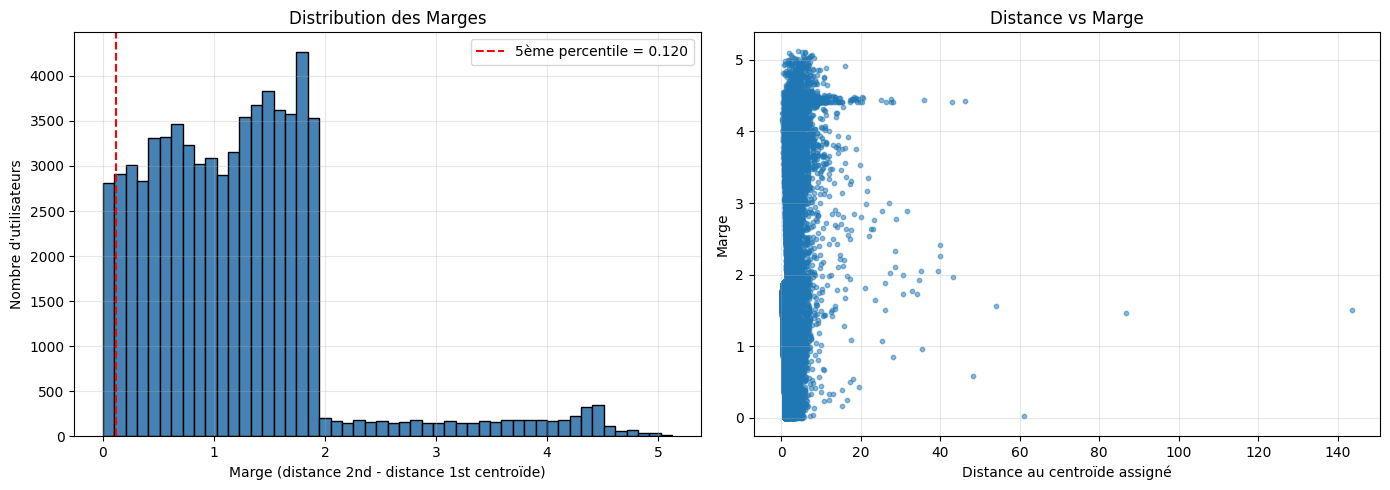


Utilisateurs ambigus (marge < 0.120): 3400 (5.00%)


In [10]:
# Calculer distances de chaque point à tous les centroïdes
distances = cdist(X_scaled, kmeans_ref.cluster_centers_, metric='euclidean')

# Distance au centroïde assigné
assigned_distances = distances[np.arange(len(X_scaled)), labels_ref]

# Distance au 2ème centroïde le plus proche
sorted_distances = np.sort(distances, axis=1)
second_closest_distances = sorted_distances[:, 1]

# Marge = différence entre 1er et 2ème centroïde le plus proche
margins = second_closest_distances - assigned_distances

# Identifier les cas limites (faible marge)
corner_cases_idx = np.argsort(margins)[:20]  # 20 cas les plus ambigus

print("=== Cas Limites (Utilisateurs Ambigus) ===\n")
corner_cases_df = user_events_sample.iloc[corner_cases_idx].copy()
corner_cases_df['margin'] = margins[corner_cases_idx]
corner_cases_df['dist_to_center'] = assigned_distances[corner_cases_idx]

print(corner_cases_df[['user_id', 'cluster', 'margin', 'dist_to_center', 
                       'total_events', 'total_purchases', 'conversion_rate']].to_string(index=False))

# Visualisation distribution des marges
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(margins, bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=np.percentile(margins, 5), color='r', linestyle='--', 
            label=f'5ème percentile = {np.percentile(margins, 5):.3f}')
plt.xlabel('Marge (distance 2nd - distance 1st centroïde)')
plt.ylabel('Nombre d\'utilisateurs')
plt.title('Distribution des Marges')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(assigned_distances, margins, alpha=0.5, s=10)
plt.xlabel('Distance au centroïde assigné')
plt.ylabel('Marge')
plt.title('Distance vs Marge')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques
ambiguous_threshold = np.percentile(margins, 5)
n_ambiguous = np.sum(margins < ambiguous_threshold)
print(f"\nUtilisateurs ambigus (marge < {ambiguous_threshold:.3f}): {n_ambiguous} ({n_ambiguous/len(margins)*100:.2f}%)")

## 5. Visualisation PCA - Projection 2D des Clusters

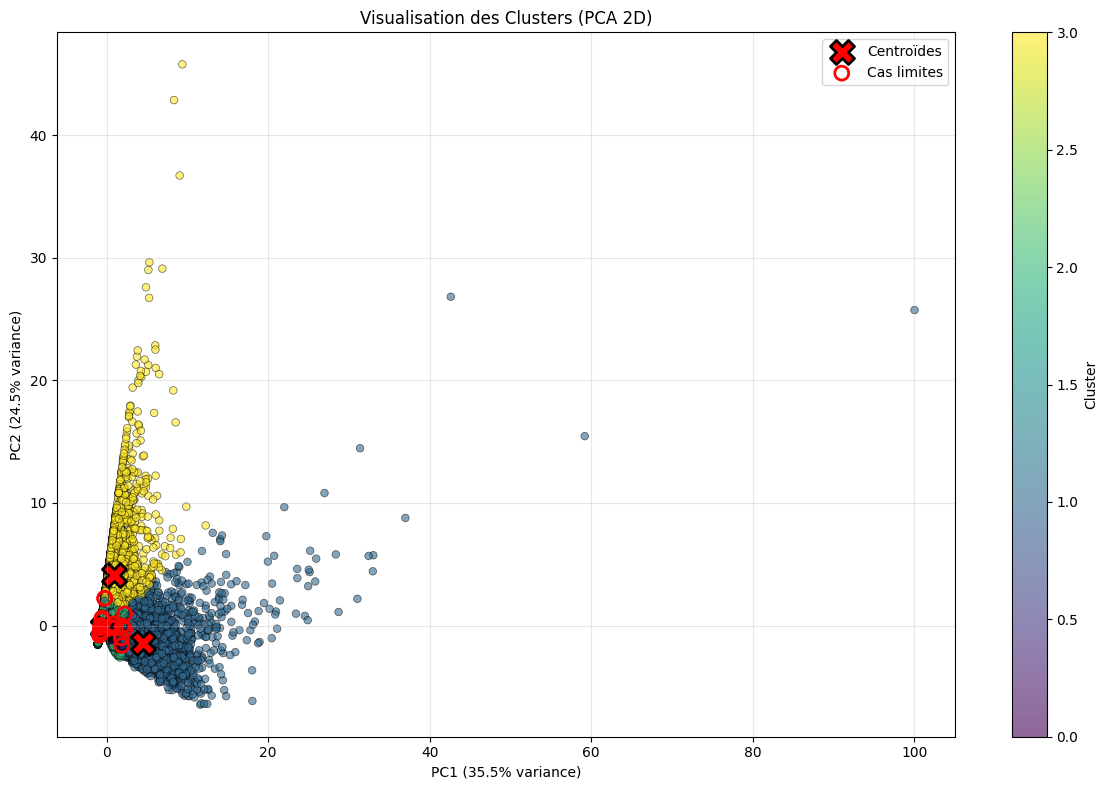

Variance expliquée par PC1+PC2: 60.05%


In [11]:
# Réduction dimensionnelle avec PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# Visualisation des clusters
plt.figure(figsize=(12, 8))

# Plot tous les points
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=labels_ref, cmap='viridis', 
                     alpha=0.6, s=30, edgecolors='k', linewidth=0.5)

# Plot centroïdes
centers_pca = pca.transform(kmeans_ref.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidth=2,
           label='Centroïdes')

# Plot cas limites
corner_X_pca = X_pca[corner_cases_idx]
plt.scatter(corner_X_pca[:, 0], corner_X_pca[:, 1], 
           c='none', edgecolors='red', s=100, linewidth=2,
           label='Cas limites')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Visualisation des Clusters (PCA 2D)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance expliquée par PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

## 6. Stabilité du Clustering (Bootstrap)
Test de la stabilité par rééchantillonnage

Test de stabilité (bootstrap)...


/tmp/ipykernel_37401/1011262874.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bootstrap_ari_scores], labels=['ARI vs Référence'])


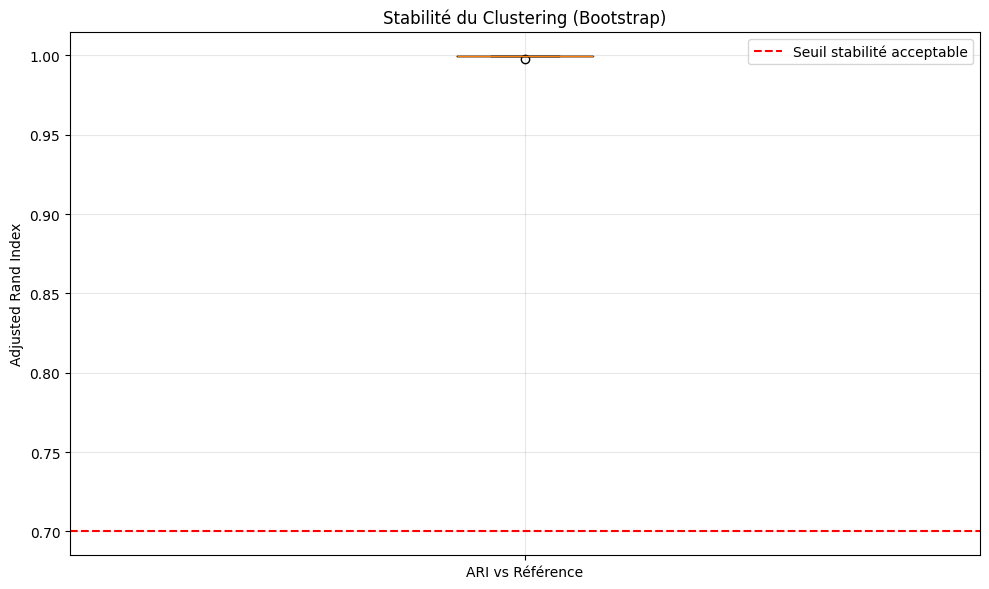


=== Stabilité Bootstrap ===
ARI moyen: 0.9995
ARI std: 0.0006
ARI min: 0.9977
ARI max: 0.9998


In [12]:
# Test de stabilité par bootstrap
n_bootstrap = 10
bootstrap_ari_scores = []

print("Test de stabilité (bootstrap)...")
for i in range(n_bootstrap):
    # Rééchantillonnage avec remplacement
    indices = np.random.choice(len(X_scaled), size=len(X_scaled), replace=True)
    X_boot = X_scaled[indices]
    
    # Clustering sur échantillon bootstrap
    kmeans_boot = KMeans(n_clusters=N_CLUSTERS, random_state=i, n_init=10)
    labels_boot_full = kmeans_boot.fit_predict(X_scaled)  # Prédire sur dataset complet
    
    # Comparer avec référence
    ari = adjusted_rand_score_clusters(labels_ref, labels_boot_full)
    bootstrap_ari_scores.append(ari)

# Visualisation
plt.figure(figsize=(10, 6))
plt.boxplot([bootstrap_ari_scores], labels=['ARI vs Référence'])
plt.axhline(y=0.7, color='r', linestyle='--', label='Seuil stabilité acceptable')
plt.ylabel('Adjusted Rand Index')
plt.title('Stabilité du Clustering (Bootstrap)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== Stabilité Bootstrap ===")
print(f"ARI moyen: {np.mean(bootstrap_ari_scores):.4f}")
print(f"ARI std: {np.std(bootstrap_ari_scores):.4f}")
print(f"ARI min: {np.min(bootstrap_ari_scores):.4f}")
print(f"ARI max: {np.max(bootstrap_ari_scores):.4f}")

## 7. Résumé des Tests

In [13]:
# Résumé complet
print("=" * 80)
print(" " * 20 + "RÉSUMÉ DES TESTS - CLUSTERING KMEANS")
print("=" * 80)

print(f"\n📊 CONFIGURATION:")
print(f"  - Nombre de clusters: {N_CLUSTERS}")
print(f"  - Nombre d'utilisateurs: {len(X_scaled)}")
print(f"  - Nombre de features: {len(feature_cols)}")

print(f"\n✅ MÉTRIQUES DE RÉFÉRENCE:")
print(f"  - Silhouette Score: {silhouette_ref:.4f} {'✓' if silhouette_ref > 0.15 else '✗'} (seuil: > 0.15)")
print(f"  - Davies-Bouldin Index: {davies_bouldin_ref:.4f} {'✓' if davies_bouldin_ref < 2.0 else '✗'} (seuil: < 2.0)")
print(f"  - Calinski-Harabasz Score: {calinski_ref:.4f}")
print(f"  - Inertia: {inertia_ref:.2f}")

print(f"\n🔧 ROBUSTESSE AU BRUIT:")
acceptable_noise = max([n for n, s in zip(noise_levels, silhouette_scores) if s > 0.15])
print(f"  - Niveau de bruit acceptable: {acceptable_noise:.2f} × std")
print(f"  - Silhouette à bruit max testé ({noise_levels[-1]}): {silhouette_scores[-1]:.4f}")

print(f"\n⚖️ ÉQUILIBRE DES CLUSTERS:")
for cluster in range(N_CLUSTERS):
    count = np.sum(labels_ref == cluster)
    print(f"  - Cluster {cluster}: {count} ({count/len(labels_ref)*100:.1f}%)")

print(f"\n🎯 CAS LIMITES:")
print(f"  - Utilisateurs ambigus (<5% marge): {n_ambiguous} ({n_ambiguous/len(margins)*100:.2f}%)")
print(f"  - Seuil de marge: {ambiguous_threshold:.3f}")

print(f"\n🔄 STABILITÉ (Bootstrap):")
stability_ok = np.mean(bootstrap_ari_scores) > 0.7
print(f"  - ARI moyen: {np.mean(bootstrap_ari_scores):.4f} {'✓' if stability_ok else '✗'} (seuil: > 0.7)")
print(f"  - ARI écart-type: {np.std(bootstrap_ari_scores):.4f}")

print("\n" + "=" * 80)

overall_status = all([
    silhouette_ref > 0.15,
    davies_bouldin_ref < 2.0,
    n_ambiguous/len(margins) < 0.10,
    stability_ok
])

if overall_status:
    print("✅ STATUT GLOBAL: PRÊT POUR PRODUCTION")
else:
    print("⚠️ STATUT GLOBAL: NÉCESSITE DES AJUSTEMENTS")
    
print("=" * 80)

                    RÉSUMÉ DES TESTS - CLUSTERING KMEANS

📊 CONFIGURATION:
  - Nombre de clusters: 4
  - Nombre d'utilisateurs: 67989
  - Nombre de features: 9

✅ MÉTRIQUES DE RÉFÉRENCE:
  - Silhouette Score: 0.2809 ✓ (seuil: > 0.15)
  - Davies-Bouldin Index: 1.1571 ✓ (seuil: < 2.0)
  - Calinski-Harabasz Score: 17605.2388
  - Inertia: 344369.67

🔧 ROBUSTESSE AU BRUIT:
  - Niveau de bruit acceptable: 0.30 × std
  - Silhouette à bruit max testé (0.3): 0.2178

⚖️ ÉQUILIBRE DES CLUSTERS:
  - Cluster 0: 27007 (39.7%)
  - Cluster 1: 5375 (7.9%)
  - Cluster 2: 31731 (46.7%)
  - Cluster 3: 3876 (5.7%)

🎯 CAS LIMITES:
  - Utilisateurs ambigus (<5% marge): 3400 (5.00%)
  - Seuil de marge: 0.120

🔄 STABILITÉ (Bootstrap):
  - ARI moyen: 0.9995 ✓ (seuil: > 0.7)
  - ARI écart-type: 0.0006

✅ STATUT GLOBAL: PRÊT POUR PRODUCTION


In [14]:
# Fermeture connexion
con.close()